# Wind Farm Yaw Control via PPO (Proximal Policy Optimization)

This notebook trains a PPO agent to maximize total power output by controlling the yaw angles of 3 turbines in the `Turb3_Row1_Floris` environment.

**Baselines to beat** (from the GP notebook, fixed wind: 8 m/s, 270°):
- Random policy:  ~228 total reward / episode  
- GP + gradient optimizer: ~232 total reward / episode

**Algorithm**: PPO with clipped surrogate objective, GAE(λ), and shared Actor-Critic backbone.

In [1]:
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal

from wfcrl import environments as envs

sns.set_theme(style="whitegrid")
SEED = 13

In [2]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## Environment Setup

In [3]:
env = envs.make(
    "Turb3_Row1_Floris",
    max_num_steps=150,
    controls={"yaw": (-45, 45, 5)},  # range in degrees, step degrees per action
    continuous_control=True,
    log=True,
)

N_TURBINES = env.num_turbines
print(f"Turbines: {N_TURBINES}")
print(f"Observation space: {env.observation_space}")
print(f"Action space:      {env.action_space}")
print(f"Controls:          {env.controls}")

Turbines: 3
Observation space: Dict('yaw': Box(-45.0, 45.0, (3,), float32), 'freewind_measurements': Box([3. 0.], [ 28. 360.], (2,), float32), 'wind_speed': Box(3.0, 28.0, (3,), float32), 'wind_direction': Box(0.0, 360.0, (3,), float32))
Action space:      Dict('yaw': Box(-5.0, 5.0, (3,), float32))
Controls:          {'yaw': (-45, 45, 5)}


In [4]:
# Precompute normalization bounds directly from the obs space
_OBS_KEYS = ["yaw", "freewind_measurements", "wind_speed", "wind_direction"]
_OBS_LOW  = np.concatenate([env.observation_space[k].low  for k in _OBS_KEYS]).astype(np.float32)
_OBS_HIGH = np.concatenate([env.observation_space[k].high for k in _OBS_KEYS]).astype(np.float32)


def flatten_obs(obs: dict) -> np.ndarray:
    """Convert Dict obs to a normalized flat vector in [-1, 1].

    Raw features span very different scales (yaw: ±20, wind direction: 0–360).
    Normalizing to [-1, 1] prevents wind-direction values from dominating the
    first linear layer and keeps all gradients on the same scale.
    """
    raw = np.concatenate([obs[k] for k in _OBS_KEYS]).astype(np.float32)
    normalized = 2.0 * (raw - _OBS_LOW) / (_OBS_HIGH - _OBS_LOW) - 1.0
    # Guard against NaN/inf from the simulator (e.g. async Floris I/O races).
    # Replace bad values with 0.0 (mid-range, safe neutral input).
    return np.nan_to_num(normalized, nan=0.0, posinf=1.0, neginf=-1.0)


def env_reset(seed_val, options):
    """Call env.reset() and always return just the obs dict."""
    result = env.reset(seed=seed_val, options=options)
    return result[0] if isinstance(result, tuple) else result


OBS_DIM = 3 + 2 + 3 + 3  # = 11
ACT_DIM = N_TURBINES       # = 3  (continuous yaw delta per turbine)
print(f"obs_dim={OBS_DIM}, act_dim={ACT_DIM}")
print(f"obs_low:  {_OBS_LOW}")
print(f"obs_high: {_OBS_HIGH}")

obs_dim=11, act_dim=3
obs_low:  [-45. -45. -45.   3.   0.   3.   3.   3.   0.   0.   0.]
obs_high: [ 45.  45.  45.  28. 360.  28.  28.  28. 360. 360. 360.]


## Actor-Critic Network

In [5]:
class ActorCritic(nn.Module):
    """
    Shared-backbone Actor-Critic for continuous actions.
    Actor: outputs a Gaussian (mean, log_std) over actions.
    Critic: outputs a scalar state value.
    """
    def __init__(self, obs_dim: int, act_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        )
        self.actor_mean    = nn.Linear(hidden_dim, act_dim)
        self.actor_log_std = nn.Parameter(torch.zeros(act_dim))  # learnable log-std
        self.critic        = nn.Linear(hidden_dim, 1)

        # Orthogonal init (standard for PPO)
        for layer in self.backbone:
            if isinstance(layer, nn.Linear):
                nn.init.orthogonal_(layer.weight, gain=np.sqrt(2))
                nn.init.zeros_(layer.bias)
        nn.init.orthogonal_(self.actor_mean.weight, gain=0.01)
        nn.init.zeros_(self.actor_mean.bias)
        nn.init.orthogonal_(self.critic.weight, gain=1.0)
        nn.init.zeros_(self.critic.bias)

    def _std(self) -> torch.Tensor:
        # Clamp log_std to [-4, 0.5] to prevent std collapsing to 0.
        # At log_std=-4, std≈0.018 (still explorative); at +0.5, std≈1.65.
        # Without this, as std→0 the stored log_probs→-inf and
        # exp(new_logp - old_logp) → nan, silently corrupting weights.
        return self.actor_log_std.clamp(-4.0, 0.5).exp()

    def _dist_from_features(self, features: torch.Tensor) -> Normal:
        mean = self.actor_mean(features)
        std  = self._std().expand_as(mean)
        return Normal(mean, std)
    
    def _dist(self, obs: torch.Tensor) -> Normal:
        features = self.backbone(obs)
        return self._dist_from_features(features)

    def act(self, obs: torch.Tensor):
        """Sample action; return (action, log_prob, value)."""
        features = self.backbone(obs)
        dist     = self._dist_from_features(features)
        action   = dist.sample()
        log_prob = dist.log_prob(action).sum(-1)
        value    = self.critic(features).squeeze(-1)
        return action, log_prob, value

    def evaluate(self, obs: torch.Tensor, action: torch.Tensor):
        """Re-evaluate stored (obs, action) pairs for the PPO loss."""
        features = self.backbone(obs)
        dist     = self._dist_from_features(features)
        log_prob = dist.log_prob(action).sum(-1)
        entropy  = dist.entropy().sum(-1)
        value    = self.critic(features).squeeze(-1)
        return log_prob, entropy, value


policy = ActorCritic(OBS_DIM, ACT_DIM).to(DEVICE)
print(policy)

ActorCritic(
  (backbone): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
  )
  (actor_mean): Linear(in_features=128, out_features=3, bias=True)
  (critic): Linear(in_features=128, out_features=1, bias=True)
)


## PPO Hyperparameters

In [6]:
# ── Training budget ───────────────────────────────────────────────────────────
N_EPISODES = 500   # 20 was far too few; PPO needs ~50K–500K timesteps
EVAL_EVERY = 50    # print progress every N episodes

# ── PPO update ────────────────────────────────────────────────────────────────
LR         = 3e-4
N_EPOCHS   = 10    # update passes per collected episode
BATCH_SIZE = 32
GAMMA      = 0.99
GAE_LAMBDA = 0.95
CLIP_EPS   = 0.2
VF_COEF    = 0.5
ENT_COEF   = 0.01  # raised from 1e-3 to encourage exploration early in training
MAX_GRAD   = 0.5

optimizer = optim.Adam(policy.parameters(), lr=LR, eps=1e-5)

## PPO Training Loop

In [7]:
def compute_gae(rewards, values, dones, gamma=GAMMA, lam=GAE_LAMBDA):
    """
    Generalized Advantage Estimation (GAE-λ).
    Episode always terminates, so bootstrap value = 0.
    """
    T          = len(rewards)
    advantages = np.zeros(T, dtype=np.float32)
    gae        = 0.0
    next_value = 0.0
    for t in reversed(range(T)):
        mask           = 1.0 - dones[t]
        delta          = rewards[t] + gamma * next_value * mask - values[t]
        gae            = delta + gamma * lam * mask * gae
        advantages[t]  = gae
        next_value     = values[t]
    returns = advantages + np.array(values, dtype=np.float32)
    return advantages, returns

In [8]:
def ppo_update(obs_buf, act_buf, logp_buf, adv_buf, ret_buf):
    """Mini-batch PPO update over N_EPOCHS passes."""
    obs_t  = torch.tensor(obs_buf,  dtype=torch.float32, device=DEVICE)
    act_t  = torch.tensor(act_buf,  dtype=torch.float32, device=DEVICE)
    logp_t = torch.tensor(logp_buf, dtype=torch.float32, device=DEVICE)
    adv_t  = torch.tensor(adv_buf,  dtype=torch.float32, device=DEVICE)
    ret_t  = torch.tensor(ret_buf,  dtype=torch.float32, device=DEVICE)

    # Bail early if any input buffer is corrupt (NaN reward, obs, etc.).
    if not all(torch.isfinite(t).all() for t in (obs_t, act_t, logp_t, adv_t, ret_t)):
        return {"pg": float("nan"), "vf": float("nan"), "ent": float("nan")}

    adv_t = (adv_t - adv_t.mean()) / (adv_t.std() + 1e-8)  # normalize advantages
    # Normalize returns so the critic target is O(1) rather than O(200).
    # Without this, VF loss dominates training and the critic never converges.
    ret_t = (ret_t - ret_t.mean()) / (ret_t.std() + 1e-8)

    # Save a parameter snapshot so we can roll back if a gradient step corrupts weights.
    snapshot = {n: p.data.clone() for n, p in policy.named_parameters()}

    N = len(obs_t)
    total_pg = total_vf = total_ent = 0.0
    n_batches = 0
    weights_ok = True

    for _ in range(N_EPOCHS):
        if not weights_ok:
            break
        for b in torch.randperm(N, device=DEVICE).split(BATCH_SIZE):
            new_logp, entropy, new_val = policy.evaluate(obs_t[b], act_t[b])

            ratio    = (new_logp - logp_t[b]).exp()

            # Skip batch if NaN crept in (e.g. from corrupt obs earlier in the episode).
            if not torch.isfinite(ratio).all():
                optimizer.zero_grad()
                continue

            pg_loss  = -torch.min(
                ratio * adv_t[b],
                torch.clamp(ratio, 1 - CLIP_EPS, 1 + CLIP_EPS) * adv_t[b]
            ).mean()
            vf_loss  = ((new_val - ret_t[b]) ** 2).mean()
            ent_loss = -entropy.mean()

            (pg_loss + VF_COEF * vf_loss + ENT_COEF * ent_loss).backward()
            nn.utils.clip_grad_norm_(policy.parameters(), MAX_GRAD)
            optimizer.step()
            optimizer.zero_grad()

            # Roll back to snapshot and abort this update if any weight went NaN.
            if not all(torch.isfinite(p).all() for p in policy.parameters()):
                for n, p in policy.named_parameters():
                    p.data.copy_(snapshot[n])
                optimizer.zero_grad()
                weights_ok = False
                break

            total_pg  += pg_loss.item()
            total_vf  += vf_loss.item()
            total_ent += ent_loss.item()
            n_batches += 1

    if n_batches == 0:
        return {"pg": float("nan"), "vf": float("nan"), "ent": float("nan")}
    return {"pg": total_pg / n_batches,
            "vf": total_vf / n_batches,
            "ent": total_ent / n_batches}


In [9]:
WIND_OPTS = {"wind_speed": 8, "wind_direction": 270}  # fixed scenario (Sc.1)

episode_rewards = []
loss_log = {"pg": [], "vf": [], "ent": []}

sim_time = 0.0  # cumulative time inside env.step()

print(f"Training to episode {N_EPISODES}...")
train_start = time.perf_counter()

for ep in range(N_EPISODES):
    obs_dict = env_reset(SEED + ep, WIND_OPTS)

    obs_buf = []
    act_buf = []
    logp_buf = []
    rew_buf = []
    val_buf = []
    done_buf = []
    ep_reward = 0.0
    done = False

    while not done:
        obs_np = flatten_obs(obs_dict)
        obs_t  = torch.tensor(obs_np, dtype=torch.float32, device=DEVICE).unsqueeze(0)

        with torch.no_grad():
            action_t, logp_t, val_t = policy.act(obs_t)

        action_np    = action_t.squeeze(0).cpu().numpy()  # (3,)
        joint_action = {"yaw": action_np}

        _t0 = time.perf_counter()
        obs_dict, reward, termination, truncation, info = env.step(joint_action)
        sim_time += time.perf_counter() - _t0

        r = float(reward[0]) if hasattr(reward, "__len__") else float(reward)

        obs_buf.append(obs_np)
        act_buf.append(action_np)
        logp_buf.append(logp_t.item())
        rew_buf.append(r)
        val_buf.append(val_t.item())
        done_buf.append(float(termination or truncation))
        ep_reward += r
        done = termination or truncation

    episode_rewards.append(ep_reward)

    adv_buf, ret_buf = compute_gae(rew_buf, val_buf, done_buf)
    losses = ppo_update(
        np.array(obs_buf), np.array(act_buf),
        np.array(logp_buf), adv_buf, ret_buf
    )
    for k, v in losses.items():
        loss_log[k].append(v)

    if (ep + 1) % EVAL_EVERY == 0:
        elapsed = time.perf_counter() - train_start
        step_pct = 100.0 * sim_time / elapsed
        recent = np.mean(episode_rewards[-EVAL_EVERY:])
        print(f"Ep {ep+1:4d} | mean reward ({EVAL_EVERY}-ep avg): {recent:.2f} "
              f"| pg={losses['pg']:.4f}  vf={losses['vf']:.4f}  ent={losses['ent']:.4f} "
              f"| step={sim_time:.1f}s/{elapsed:.1f}s ({step_pct:.1f}%)")

total_train_time = time.perf_counter() - train_start
print(f"\nTraining complete.")
print(f"  Total time   : {total_train_time:.1f}s")
print(f"  env.step time: {sim_time:.1f}s ({100.*sim_time/total_train_time:.1f}% of total)")

Training to episode 500...
Ep   50 | mean reward (50-ep avg): 218.33 | pg=-0.0325  vf=0.8559  ent=-4.3797 | step=64.2s/147.4s (43.5%)
Ep  100 | mean reward (50-ep avg): 215.94 | pg=-0.0133  vf=0.6776  ent=-4.5419 | step=132.0s/303.1s (43.6%)


c:\Users\zjpeh\Downloads\Code\Weather Vein\weather-vein\.venv\Lib\site-packages\floris\simulation\wake_deflection\gauss.py:156: RuntimeWarning: divide by zero encountered in divide
  freestream_velocity
c:\Users\zjpeh\Downloads\Code\Weather Vein\weather-vein\.venv\Lib\site-packages\floris\simulation\wake_deflection\gauss.py:196: RuntimeWarning: divide by zero encountered in divide
  delta_near_wake = ((x - xR) / (x0 - xR)) * delta0 + (self.ad + self.bd * (x - x_i))
c:\Users\zjpeh\Downloads\Code\Weather Vein\weather-vein\.venv\Lib\site-packages\floris\simulation\wake_deflection\gauss.py:196: RuntimeWarning: invalid value encountered in divide
  delta_near_wake = ((x - xR) / (x0 - xR)) * delta0 + (self.ad + self.bd * (x - x_i))
c:\Users\zjpeh\Downloads\Code\Weather Vein\weather-vein\.venv\Lib\site-packages\floris\simulation\wake_deflection\gauss.py:196: RuntimeWarning: invalid value encountered in multiply
  delta_near_wake = ((x - xR) / (x0 - xR)) * delta0 + (self.ad + self.bd * (x - x_

Ep  150 | mean reward (50-ep avg): 223.56 | pg=-0.0258  vf=0.4550  ent=-4.6535 | step=201.1s/462.6s (43.5%)
Ep  200 | mean reward (50-ep avg): 232.09 | pg=-0.0142  vf=0.8897  ent=-4.7569 | step=270.9s/620.5s (43.7%)
Ep  250 | mean reward (50-ep avg): 228.25 | pg=-0.0220  vf=0.5731  ent=-5.0359 | step=341.7s/776.4s (44.0%)
Ep  300 | mean reward (50-ep avg): 229.11 | pg=-0.0146  vf=1.2238  ent=-5.1697 | step=415.3s/925.2s (44.9%)
Ep  350 | mean reward (50-ep avg): 235.76 | pg=0.0062  vf=0.3186  ent=-5.3638 | step=483.1s/1070.0s (45.1%)
Ep  400 | mean reward (50-ep avg): 245.45 | pg=0.0017  vf=0.6887  ent=-5.5619 | step=551.0s/1215.0s (45.3%)
Ep  450 | mean reward (50-ep avg): 248.54 | pg=-0.0072  vf=0.4203  ent=-5.7568 | step=619.9s/1364.8s (45.4%)
Ep  500 | mean reward (50-ep avg): 242.78 | pg=-0.0093  vf=0.9656  ent=-5.7568 | step=693.1s/1513.9s (45.8%)

Training complete.
  Total time   : 1513.9s
  env.step time: 693.1s (45.8% of total)


## Learning Curves

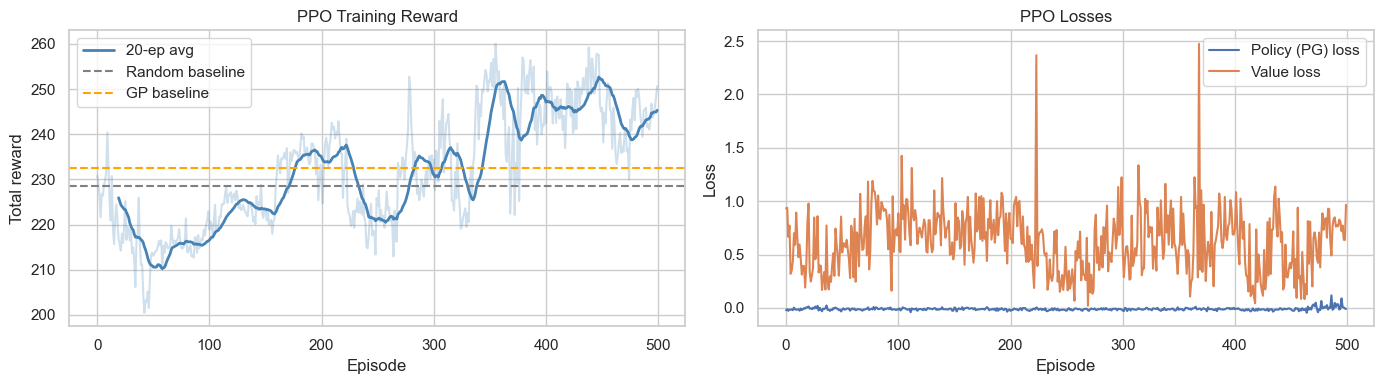

In [10]:
WINDOW   = 20
smoothed = np.convolve(episode_rewards, np.ones(WINDOW) / WINDOW, mode="valid")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(episode_rewards, alpha=0.25, color="steelblue")
ax.plot(np.arange(WINDOW - 1, len(episode_rewards)), smoothed,
        color="steelblue", linewidth=2, label=f"{WINDOW}-ep avg")
ax.axhline(228.44, color="gray",   linestyle="--", label="Random baseline")
ax.axhline(232.49, color="orange", linestyle="--", label="GP baseline")
ax.set_xlabel("Episode")
ax.set_ylabel("Total reward")
ax.set_title("PPO Training Reward")
ax.legend()

ax = axes[1]
ax.plot(loss_log["pg"],  label="Policy (PG) loss")
ax.plot(loss_log["vf"],  label="Value loss")
ax.set_xlabel("Episode")
ax.set_ylabel("Loss")
ax.set_title("PPO Losses")
ax.legend()

plt.tight_layout()
plt.show()

## Evaluation: Greedy Policy Rollout

Run the trained policy deterministically (actor mean only, no sampling noise).

In [11]:
def evaluate_policy(n_episodes: int = 5, greedy: bool = True, seed_offset: int = 9000):
    """Return episode reward list and a DataFrame of the first episode's trajectory."""
    policy.eval()
    rewards   = []
    eval_rows = []

    with torch.no_grad():
        for ep in range(n_episodes):
            obs_dict = env_reset(seed_offset + ep, WIND_OPTS)
            done, total_r, step = False, 0.0, 0

            while not done:
                obs_np   = flatten_obs(obs_dict)
                obs_t    = torch.tensor(obs_np, dtype=torch.float32,
                                        device=DEVICE).unsqueeze(0)
                features = policy.backbone(obs_t)
                action_t = policy.actor_mean(features) if greedy else policy.act(obs_t)[0]
                action_np    = np.clip(action_t.squeeze(0).cpu().numpy(), -1.0, 1.0)
                joint_action = {"yaw": action_np}

                obs_dict, reward, termination, truncation, info = env.step(joint_action)
                r        = float(reward[0]) if hasattr(reward, "__len__") else float(reward)
                total_r += r

                if ep == 0:
                    eval_rows.append({
                        "step":   step,
                        "reward": r,
                        **{f"yaw_{i}":   obs_dict["yaw"][i]   for i in range(N_TURBINES)},
                        **{f"power_{i}": info["power"][i]     for i in range(N_TURBINES)},
                    })
                step += 1
                done = termination or truncation

            rewards.append(total_r)

    policy.train()
    return rewards, pd.DataFrame(eval_rows)


eval_rewards, eval_df = evaluate_policy(n_episodes=5)
print(f"Eval total rewards: {[f'{r:.2f}' for r in eval_rewards]}")
print(f"Mean ± std:  {np.mean(eval_rewards):.2f} ± {np.std(eval_rewards):.2f}")

Eval total rewards: ['251.29', '251.29', '251.29', '251.29', '251.29']
Mean ± std:  251.29 ± 0.00


## Yaw Angles and Power Over a Representative Episode

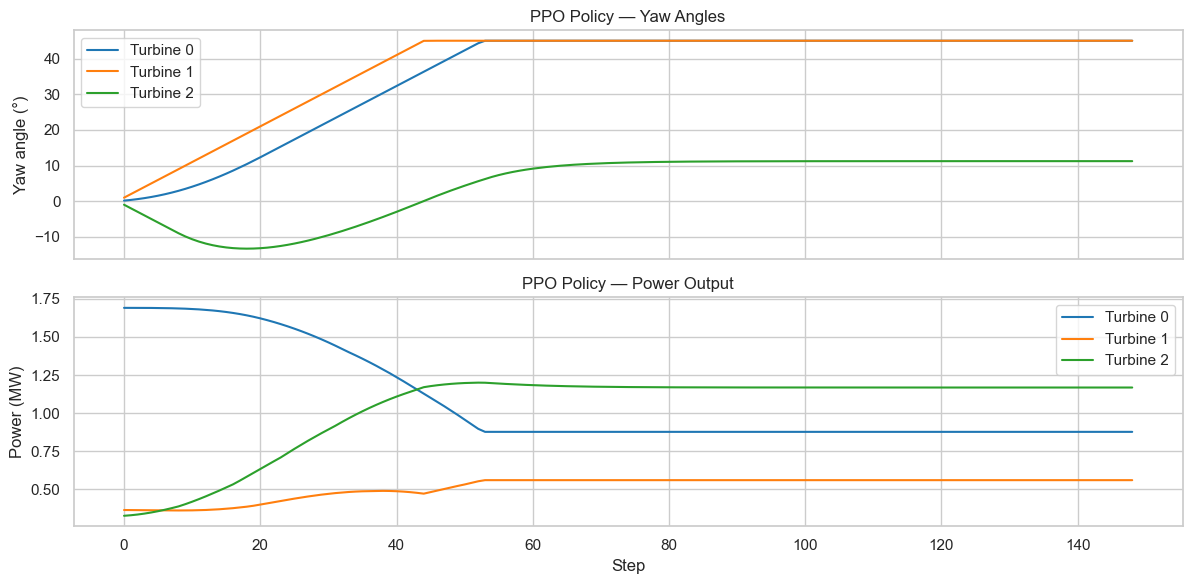

In [12]:
colors = sns.color_palette("tab10", N_TURBINES)
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax = axes[0]
for i in range(N_TURBINES):
    ax.plot(eval_df["step"], eval_df[f"yaw_{i}"],
            color=colors[i], label=f"Turbine {i}")
ax.set_ylabel("Yaw angle (°)")
ax.set_title("PPO Policy — Yaw Angles")
ax.legend()

ax = axes[1]
for i in range(N_TURBINES):
    ax.plot(eval_df["step"], eval_df[f"power_{i}"],
            color=colors[i], label=f"Turbine {i}")
ax.set_xlabel("Step")
ax.set_ylabel("Power (MW)")
ax.set_title("PPO Policy — Power Output")
ax.legend()

plt.tight_layout()
plt.show()

In [13]:

for i in range(N_TURBINES):
    print(f"{i}: {eval_df['step'].iloc[0]}, {eval_df[f'yaw_{i}'].iloc[0]}")

0: 0, 0.15339891612529755
1: 0, 0.974365234375
2: 0, -1.0


In [14]:
# print the last step's yaw angles for each turbine
n_turbines = len([c for c in eval_df.columns if c.startswith("yaw_")])
for i in range(n_turbines):
    print(f"{i}: {eval_df['step'].iloc[-1]}, {eval_df[f'yaw_{i}'].iloc[-1]}")

0: 148, 45.0
1: 148, 45.0
2: 148, 11.221380233764648


## Final Comparison

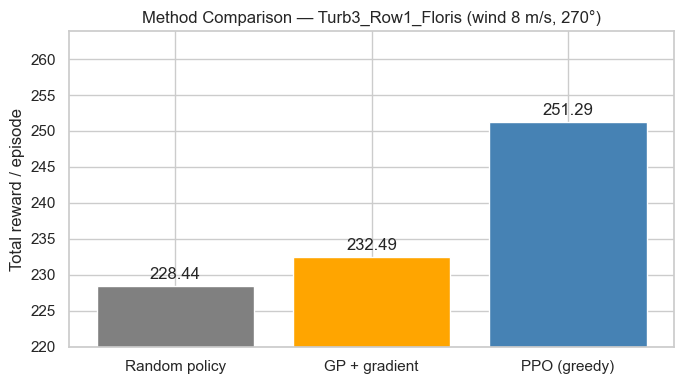


Summary:
  Random policy       : 228.44
  GP + gradient       : 232.49
  PPO (greedy)        : 251.29


In [15]:
results = {
    "Random policy": 228.44,
    "GP + gradient": 232.49,
    "PPO (greedy)":  np.mean(eval_rewards),
}

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(results.keys(), results.values(),
              color=["gray", "orange", "steelblue"])
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.set_ylabel("Total reward / episode")
ax.set_title("Method Comparison — Turb3_Row1_Floris (wind 8 m/s, 270°)")
ax.set_ylim(220, max(results.values()) * 1.05)
plt.tight_layout()
plt.show()

print("\nSummary:")
for name, val in results.items():
    print(f"  {name:<20s}: {val:.2f}")